In [4]:
#First of all, lets obtain the data and import the necessary libraries


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from random import randint
splits = {'train': 'train.csv', 'validation': 'validation.csv', 'test': 'test.csv'}
df = pd.read_csv("hf://datasets/aai510-group1/telco-customer-churn/" + splits["train"])


selected_columns = [
    'Age', 'Senior Citizen', 'Married', 'Tenure in Months', 'Monthly Charge',
    'Contract', 'Satisfaction Score', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Internet Type', 'Under 30', 'CLTV', 'Churn'
]
df = df.loc[0:199, selected_columns]
df.shape

(200, 14)

In [5]:
#Take the information about the data and summary of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 200 non-null    int64  
 1   Senior Citizen      200 non-null    int64  
 2   Married             200 non-null    int64  
 3   Tenure in Months    200 non-null    int64  
 4   Monthly Charge      200 non-null    float64
 5   Contract            200 non-null    object 
 6   Satisfaction Score  200 non-null    int64  
 7   Streaming TV        200 non-null    int64  
 8   Streaming Movies    200 non-null    int64  
 9   Streaming Music     200 non-null    int64  
 10  Internet Type       164 non-null    object 
 11  Under 30            200 non-null    int64  
 12  CLTV                200 non-null    int64  
 13  Churn               200 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 22.0+ KB


In [52]:
df.describe()

,Age,Senior Citizen,Married,Tenure in Months,Monthly Charge,Satisfaction Score,Streaming TV,Streaming Movies,Streaming Music,Under 30,CLTV,Churn
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,47.980000,0.190000,0.475000,32.805000,66.606500,3.295000,0.395000,0.400000,0.340000,0.160000,4416.975000,0.255000
std,17.308017,0.393285,0.500628,24.301022,29.169884,1.176818,0.490077,0.491127,0.474898,0.367526,1178.259556,0.436955
min,19.000000,0.000000,0.000000,1.000000,18.700000,1.000000,0.000000,0.000000,0.000000,0.000000,2007.000000,0.000000
25%,33.000000,0.000000,0.000000,9.750000,44.525000,3.000000,0.000000,0.000000,0.000000,0.000000,3458.500000,0.000000
50%,47.500000,0.000000,0.000000,30.500000,71.450000,3.000000,0.000000,0.000000,0.000000,0.000000,4562.000000,0.000000
75%,62.000000,0.000000,1.000000,56.000000,91.250000,4.000000,1.000000,1.000000,1.000000,0.000000,5416.500000,1.000000
max,80.000000,1.000000,1.000000,72.000000,116.250000,5.000000,1.000000,1.000000,1.000000,1.000000,6483.000000,1.000000


In [53]:
#Lets check if there is null values
df.isnull().sum()

Age                    0
Senior Citizen         0
Married                0
Tenure in Months       0
Monthly Charge         0
Contract               0
Satisfaction Score     0
Streaming TV           0
Streaming Movies       0
Streaming Music        0
Internet Type         36
Under 30               0
CLTV                   0
Churn                  0
dtype: int64

In [54]:
df.head()

,Age,Senior Citizen,Married,Tenure in Months,Monthly Charge,Contract,Satisfaction Score,Streaming TV,Streaming Movies,Streaming Music,Internet Type,Under 30,CLTV,Churn
0,72,1,1,25,88.40,Two Year,3,0,1,1,Fiber Optic,0,4849,0
1,27,0,0,35,95.50,Month-to-Month,3,1,0,0,Fiber Optic,1,3715,0
2,59,0,1,46,19.60,Month-to-Month,5,0,0,0,NaN,0,5092,0
3,25,0,1,27,45.85,One Year,4,0,1,1,DSL,1,2068,0
4,31,0,1,58,60.30,One Year,2,0,0,0,Cable,0,4026,1


In [55]:
#Get rid of the null data 
df["Internet Type"] = df["Internet Type"].replace(np.nan,"No Type")


In [56]:
df.head()

,Age,Senior Citizen,Married,Tenure in Months,Monthly Charge,Contract,Satisfaction Score,Streaming TV,Streaming Movies,Streaming Music,Internet Type,Under 30,CLTV,Churn
0,72,1,1,25,88.40,Two Year,3,0,1,1,Fiber Optic,0,4849,0
1,27,0,0,35,95.50,Month-to-Month,3,1,0,0,Fiber Optic,1,3715,0
2,59,0,1,46,19.60,Month-to-Month,5,0,0,0,No Type,0,5092,0
3,25,0,1,27,45.85,One Year,4,0,1,1,DSL,1,2068,0
4,31,0,1,58,60.30,One Year,2,0,0,0,Cable,0,4026,1


In [57]:
df.describe()

,Age,Senior Citizen,Married,Tenure in Months,Monthly Charge,Satisfaction Score,Streaming TV,Streaming Movies,Streaming Music,Under 30,CLTV,Churn
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,47.980000,0.190000,0.475000,32.805000,66.606500,3.295000,0.395000,0.400000,0.340000,0.160000,4416.975000,0.255000
std,17.308017,0.393285,0.500628,24.301022,29.169884,1.176818,0.490077,0.491127,0.474898,0.367526,1178.259556,0.436955
min,19.000000,0.000000,0.000000,1.000000,18.700000,1.000000,0.000000,0.000000,0.000000,0.000000,2007.000000,0.000000
25%,33.000000,0.000000,0.000000,9.750000,44.525000,3.000000,0.000000,0.000000,0.000000,0.000000,3458.500000,0.000000
50%,47.500000,0.000000,0.000000,30.500000,71.450000,3.000000,0.000000,0.000000,0.000000,0.000000,4562.000000,0.000000
75%,62.000000,0.000000,1.000000,56.000000,91.250000,4.000000,1.000000,1.000000,1.000000,0.000000,5416.500000,1.000000
max,80.000000,1.000000,1.000000,72.000000,116.250000,5.000000,1.000000,1.000000,1.000000,1.000000,6483.000000,1.000000


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 200 non-null    int64  
 1   Senior Citizen      200 non-null    int64  
 2   Married             200 non-null    int64  
 3   Tenure in Months    200 non-null    int64  
 4   Monthly Charge      200 non-null    float64
 5   Contract            200 non-null    object 
 6   Satisfaction Score  200 non-null    int64  
 7   Streaming TV        200 non-null    int64  
 8   Streaming Movies    200 non-null    int64  
 9   Streaming Music     200 non-null    int64  
 10  Internet Type       200 non-null    object 
 11  Under 30            200 non-null    int64  
 12  CLTV                200 non-null    int64  
 13  Churn               200 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 22.0+ KB


In [59]:
#Lets start EDA
df.head()

,Age,Senior Citizen,Married,Tenure in Months,Monthly Charge,Contract,Satisfaction Score,Streaming TV,Streaming Movies,Streaming Music,Internet Type,Under 30,CLTV,Churn
0,72,1,1,25,88.40,Two Year,3,0,1,1,Fiber Optic,0,4849,0
1,27,0,0,35,95.50,Month-to-Month,3,1,0,0,Fiber Optic,1,3715,0
2,59,0,1,46,19.60,Month-to-Month,5,0,0,0,No Type,0,5092,0
3,25,0,1,27,45.85,One Year,4,0,1,1,DSL,1,2068,0
4,31,0,1,58,60.30,One Year,2,0,0,0,Cable,0,4026,1


In [60]:
import random
random.seed(42)

In [61]:
from scipy.stats import normaltest

# List of columns to test
columns_to_test = ["Age", "Tenure in Months", "Monthly Charge", "CLTV"]

# Iterate over each column and perform the normality test
for column in columns_to_test:
    stat, p = normaltest(df[column])
    print(f'Column: {column} - Statistics={stat:.3f}, p={p:.3f}')
    
    # Interpret the result
    alpha = 0.05
    if p > alpha:
        print(f'Sample in column {column} looks Gaussian (fail to reject H0)')
    else:
        print(f'Sample in column {column} does not look Gaussian (reject H0)')

Column: Age - Statistics=68.445, p=0.000
Sample in column Age does not look Gaussian (reject H0)
Column: Tenure in Months - Statistics=400.985, p=0.000
Sample in column Tenure in Months does not look Gaussian (reject H0)
Column: Monthly Charge - Statistics=58.977, p=0.000
Sample in column Monthly Charge does not look Gaussian (reject H0)
Column: CLTV - Statistics=28.400, p=0.000
Sample in column CLTV does not look Gaussian (reject H0)


In [62]:
from sklearn.preprocessing import StandardScaler

# Select the numerical columns you want to normalize
numerical_features = ["Age", "Tenure in Months", "Monthly Charge", "CLTV"]

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Check the first few rows to see the normalized data
print(df.head())

        Age  Senior Citizen  Married  Tenure in Months  Monthly Charge  \
0  1.391279               1        1         -0.321986        0.748998   
1 -1.215197               0        0          0.090552        0.993011   
2  0.638297               0        1          0.544344       -1.615518   
3 -1.331040               0        1         -0.239478       -0.713359   
4 -0.983510               0        1          1.039389       -0.216742   

         Contract  Satisfaction Score  Streaming TV  Streaming Movies  \
0        Two Year                   3             0                 1   
1  Month-to-Month                   3             1                 0   
2  Month-to-Month                   5             0                 0   
3        One Year                   4             0                 1   
4        One Year                   2             0                 0   

   Streaming Music Internet Type  Under 30      CLTV  Churn  
0                1   Fiber Optic         0  0.367584  

Text(0.5, 1.0, 'The Relationship Between Age and Streaming Music')

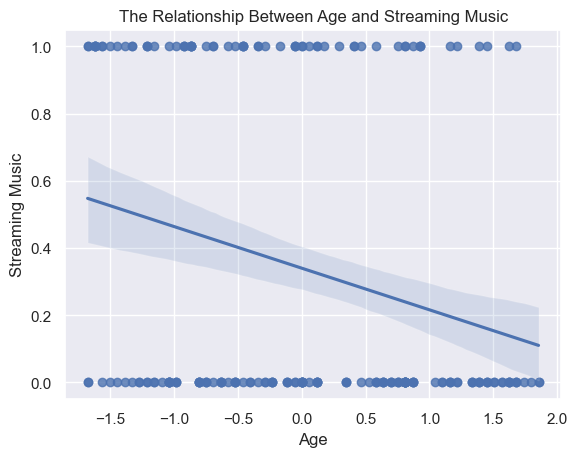

In [63]:
#First of all, lets see if there is correlation between Age and Streaming Music
sns.set_theme(style="darkgrid")

sns.regplot(x="Age", y="Streaming Music", data=df)
plt.title("The Relationship Between Age and Streaming Music")

In [64]:
np.corrcoef(df["Age"],df["Streaming Music"])

array([[ 1.        , -0.26144363],
       [-0.26144363,  1.        ]])

We can see that when age increasing , people tend to stream less music in the internet.

Text(0.5, 1.0, "The Bar Graph of 'Under 30' and Streming Music")

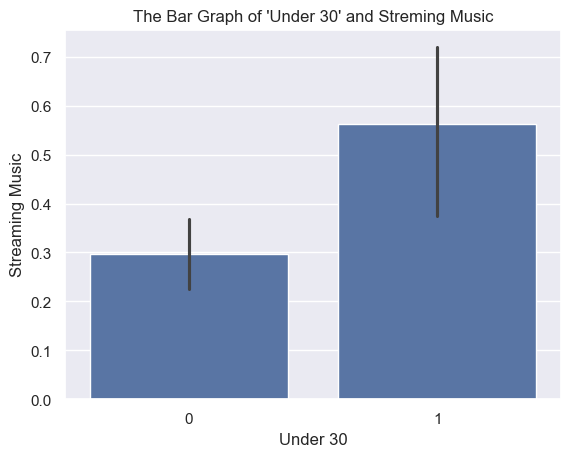

In [65]:
sns.barplot(data = df,x="Under 30",y = "Streaming Music")
plt.title("The Bar Graph of 'Under 30' and Streming Music")

Also, we can see that people who under 30 tend to stream music on the internet.

Text(0.5, 1.0, 'Relationship Between CLTV and Monthly Charge')

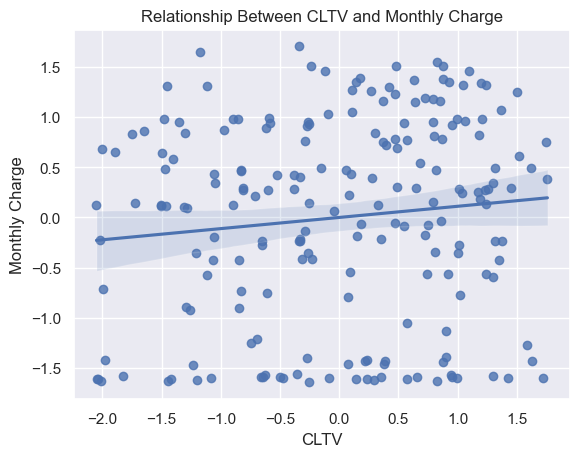

In [66]:
#Lets check the relationship between CLTV and monthly charge
sns.set_theme(style="darkgrid")

sns.regplot(x="CLTV", y="Monthly Charge", data=df)
plt.title("Relationship Between CLTV and Monthly Charge")

In [67]:
np.corrcoef(df["CLTV"],df["Monthly Charge"])

array([[1.        , 0.11138465],
       [0.11138465, 1.        ]])

It looks like there is not a strong relationship between CLTV and Monthly Charge.

Text(0.5, 1.0, 'Bar Graph of Internet Type and Monthly Charge')

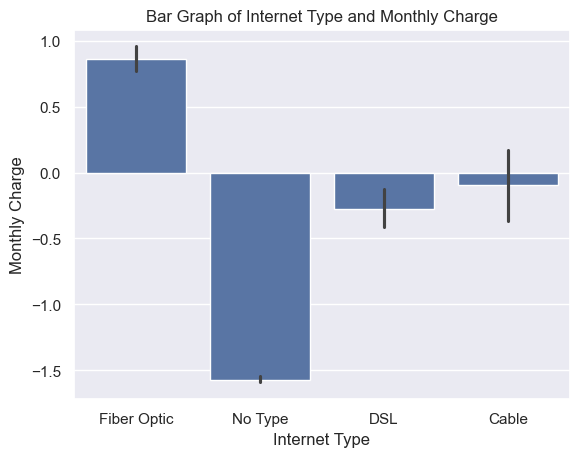

In [68]:
#Lets show if there is a relationship between Internet Type and Mothly Charge.

sns.set_theme(style="darkgrid")

sns.barplot(x="Internet Type", y="Monthly Charge", data=df)
plt.title("Bar Graph of Internet Type and Monthly Charge")

We can say that when the power of internet increase, the bill of the internet also increase (Which is normal thing)

Text(0.5, 1.0, "Bar Graph of 'Under 30' and Churn")

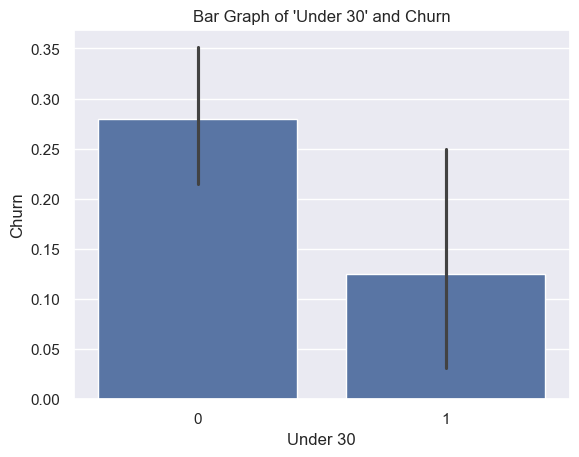

In [69]:
#Lets check the relationship of Churn and other features
#First of all, Churn vs Under 30

sns.set_theme(style="darkgrid")
sns.barplot(x="Under 30", y="Churn", data=df)
plt.title("Bar Graph of 'Under 30' and Churn")

There is not a good info in this graph, lets check other thing.


Text(0.5, 1.0, "Relationship between 'Age' and Churn")

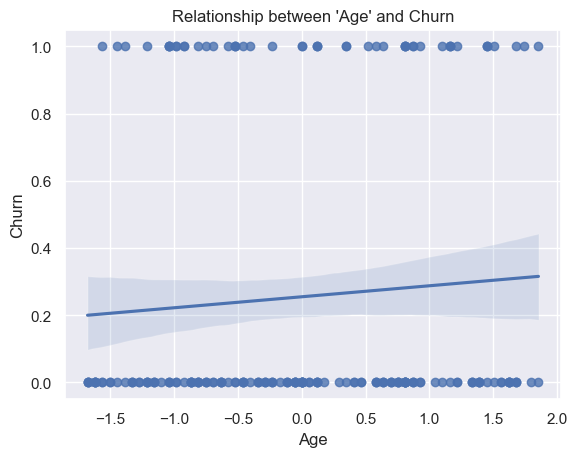

In [96]:
sns.set_theme(style="darkgrid")

sns.regplot(x="Age", y="Churn", data=df)
plt.title("Relationship between 'Age' and Churn")

In [71]:
np.corrcoef(df["Age"],df["Churn"])

array([[1.        , 0.07509625],
       [0.07509625, 1.        ]])

There is a weak positive relationship between age and churn, but there is not a significant relationship in there.

In [72]:
df.head()

,Age,Senior Citizen,Married,Tenure in Months,Monthly Charge,Contract,Satisfaction Score,Streaming TV,Streaming Movies,Streaming Music,Internet Type,Under 30,CLTV,Churn
0,1.391279,1,1,-0.321986,0.748998,Two Year,3,0,1,1,Fiber Optic,0,0.367584,0
1,-1.215197,0,0,0.090552,0.993011,Month-to-Month,3,1,0,0,Fiber Optic,1,-0.597268,0
2,0.638297,0,1,0.544344,-1.615518,Month-to-Month,5,0,0,0,No Type,0,0.574338,0
3,-1.331040,0,1,-0.239478,-0.713359,One Year,4,0,1,1,DSL,1,-1.998600,0
4,-0.983510,0,1,1.039389,-0.216742,One Year,2,0,0,0,Cable,0,-0.332657,1


<Axes: xlabel='Internet Type', ylabel='Churn'>

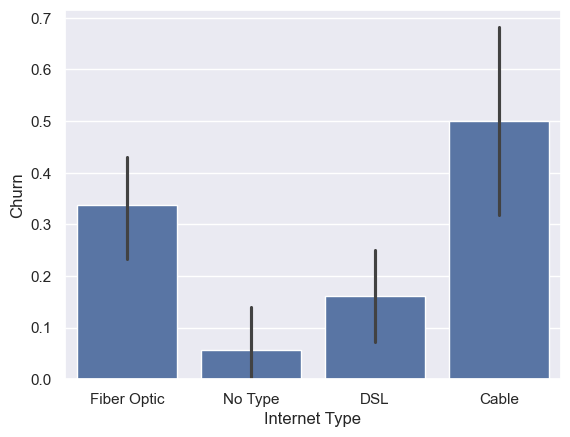

In [73]:
#Lets check Churn vs Internet Type then.
sns.barplot(data = df, x = "Internet Type",y="Churn")

We can clearly see that when the power of internet increasing, people tend to stay on that telecommunication platform for a longer time.

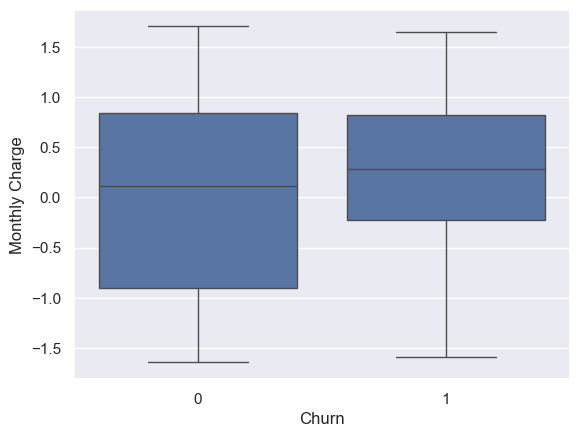

In [74]:
#Lets check Churn vs Mothly Charge
sns.boxplot(data = df, x="Churn",y="Monthly Charge")

There are some interesting insights in this graph, first of all:

-For mean, people tend to pay little higher when they stay on the telecomminication company.

-For interquartile ranges, people may want to pay higher when both they will stay on that telecomminication company, but when they want to pay 
little (or have to, it depends) people will quit from that company. 

-For wishker, both groups' whiskers show a similar range of monthly charges, with a lower bound around 20 and an upper bound near 120.

-Both groups have outliers.

In [75]:
df.head()

,Age,Senior Citizen,Married,Tenure in Months,Monthly Charge,Contract,Satisfaction Score,Streaming TV,Streaming Movies,Streaming Music,Internet Type,Under 30,CLTV,Churn
0,1.391279,1,1,-0.321986,0.748998,Two Year,3,0,1,1,Fiber Optic,0,0.367584,0
1,-1.215197,0,0,0.090552,0.993011,Month-to-Month,3,1,0,0,Fiber Optic,1,-0.597268,0
2,0.638297,0,1,0.544344,-1.615518,Month-to-Month,5,0,0,0,No Type,0,0.574338,0
3,-1.331040,0,1,-0.239478,-0.713359,One Year,4,0,1,1,DSL,1,-1.998600,0
4,-0.983510,0,1,1.039389,-0.216742,One Year,2,0,0,0,Cable,0,-0.332657,1


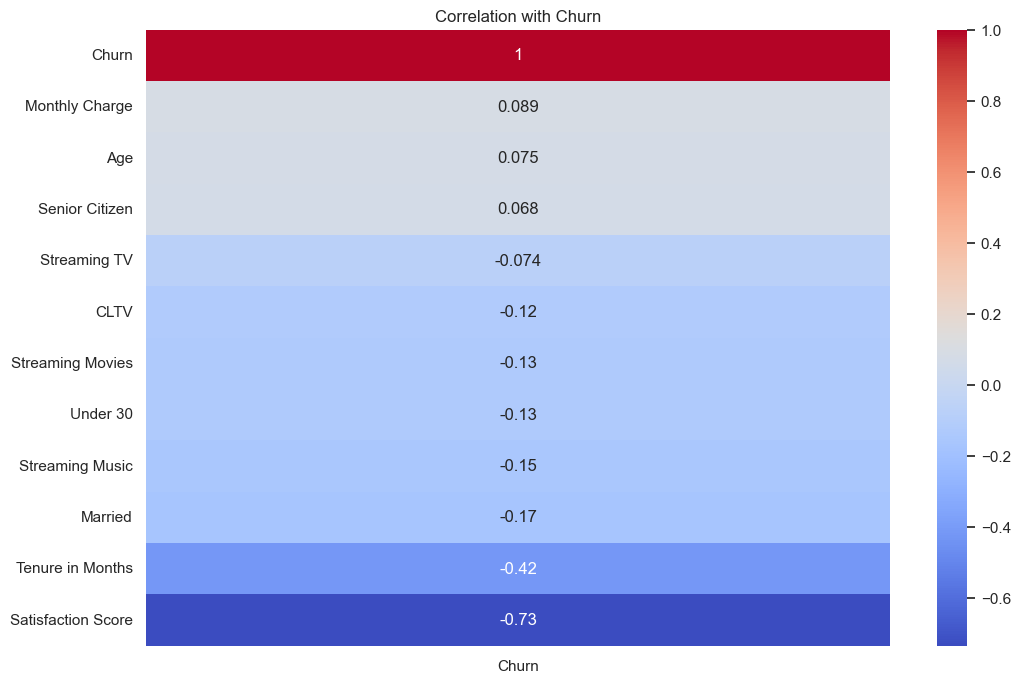

In [76]:
#Lets check a heatmap for better understanding.

correlation = df.drop(["Contract","Internet Type"],axis=1).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation[['Churn']].sort_values(by='Churn', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlation with Churn")
plt.show()

When we check the heatmap, we can see two strong relationship for Churn;

-First of all, Churn has a negative strong relationship between Satisfaction Score, which means that (normally) when people are satisfied with the service, they will stay on that service.

-Secondly, Churn has a negative strong relationship for Tenure in Months, which means that when an employee have a problem in the telecomminication company, they also leave the service that the company provide.

In [77]:
df.head()

,Age,Senior Citizen,Married,Tenure in Months,Monthly Charge,Contract,Satisfaction Score,Streaming TV,Streaming Movies,Streaming Music,Internet Type,Under 30,CLTV,Churn
0,1.391279,1,1,-0.321986,0.748998,Two Year,3,0,1,1,Fiber Optic,0,0.367584,0
1,-1.215197,0,0,0.090552,0.993011,Month-to-Month,3,1,0,0,Fiber Optic,1,-0.597268,0
2,0.638297,0,1,0.544344,-1.615518,Month-to-Month,5,0,0,0,No Type,0,0.574338,0
3,-1.331040,0,1,-0.239478,-0.713359,One Year,4,0,1,1,DSL,1,-1.998600,0
4,-0.983510,0,1,1.039389,-0.216742,One Year,2,0,0,0,Cable,0,-0.332657,1


In [78]:
#Lets start inference mean about the vector of a data
#First of all, we need to obtain the numerical values in data


df_numerical = df[["Age","Tenure in Months","Monthly Charge","CLTV","Churn"]]
df_numerical.rename(columns={'Age': 'Age', 'Tenure in Months': 'Tenure_in_Months', 'Monthly Charge': 'Monthly_Charge',"CLTV":"CLTV"}, inplace=True)
df_numerical.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_12188\179924765.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numerical.rename(columns={'Age': 'Age', 'Tenure in Months': 'Tenure_in_Months', 'Monthly Charge': 'Monthly_Charge',"CLTV":"CLTV"}, inplace=True)


,Age,Tenure_in_Months,Monthly_Charge,CLTV,Churn
0,1.391279,-0.321986,0.748998,0.367584,0
1,-1.215197,0.090552,0.993011,-0.597268,0
2,0.638297,0.544344,-1.615518,0.574338,0
3,-1.331040,-0.239478,-0.713359,-1.998600,0
4,-0.983510,1.039389,-0.216742,-0.332657,1


In [79]:
#The we need to perform multivariate hypothesis test
#Null Hypothesis = Every mean is equal to each other.
#Alternative Hypothesis = There are at least one different mean among each other.


from scipy.stats import f
import numpy as np

#The data we want to evaluate
X = df_numerical.values
mu_0 = [65, 40, 80, 3000,0.5]  # Hypothesized mean vector

# Compute Sample Mean and Covariance
n = len(X)
p = X.shape[1]
X_mean = np.mean(X, axis=0)
S = np.cov(X, rowvar=False)

# Hotelling's T^2 statistic
T2 = n * (X_mean - mu_0).T @ np.linalg.inv(S) @ (X_mean - mu_0)

# Convert to F-statistic for inference
F_stat = T2 * (n - p) / (p * (n - 1))
p_value = 1 - f.cdf(F_stat, p, n - p)
print(f"Hotelling's T² Statistic: {T2}, p-value: {p_value}")



Hotelling's T² Statistic: 2046881224.319977, p-value: 1.1102230246251565e-16


p_value is less than alpha = 0.05, so we need to reject null hyptohesis, that means there are at least one different mean among all means.

In [80]:
#Lets apply MANOVA 

from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula("Age + Tenure_in_Months + Monthly_Charge + CLTV ~ Churn", data=df_numerical)
print(manova.mv_test())


                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.9352 4.0000 195.0000  3.3782 0.0107
         Pillai's trace 0.0648 4.0000 195.0000  3.3782 0.0107
 Hotelling-Lawley trace 0.0693 4.0000 195.0000  3.3782 0.0107
    Roy's greatest root 0.0693 4.0000 195.0000  3.3782 0.0107
-------------------------------------------------------------
                                                             
-------------------------------------------------------------
         Churn          Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.7863 4.0000 195.0000 13.2479 0.0000
         Pillai's trace 0.2137 4.0000 195.0000 13.2479 0.0000
 Hotelling-Lawley trace 0.

For Intercept part, every p value is equal to 0.0107 which is less than alpha = 0.05. Hence, we will reject the null hypothesis which shows that the means of the intercepts are not equal.

For Churn part, every F value is equal to 0 which is less than alpha = 0.05. Hence, we will reject the null hypothesis which shows that the means of the churns are not equal. There is a multivariate difference between churn groups.

In [81]:
#Lets try to classify the data and apply discrimination
#First of all, we need to obtain some libraries to use
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [82]:
#Then lets provide test and train data sets
#Since we work on Churn Rate as the main feature, lets create X and y values
#Lets encode the categorical variables in X
X = df.drop("Churn",axis = 1)
label_encoder = LabelEncoder()
X["Contract"] = label_encoder.fit_transform(X["Contract"])
X["Internet Type"]= label_encoder.fit_transform(X["Internet Type"])


y = df["Churn"]

X_train,X_test,y_train,y_test = train_test_split(X,y, train_size=0.8,test_size = 0.2, random_state=2)

In [83]:
#Lets use some methods to classify
#First of all, we can use Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.975
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        31
           1       1.00      0.89      0.94         9

    accuracy                           0.97        40
   macro avg       0.98      0.94      0.96        40
weighted avg       0.98      0.97      0.97        40



When we use Logistic Regression for classification:

1- Our accuracy score is 0.97 which shows that our model performs too well, there might be an overfitting problem.

2 - Precision score when churn rate is 0 equal to 0.97 and precision score when churn rate is 1 equal to 1 which shows that our model predict positive values perfectly.

3- Recall score when churn rate is 0 equal to 1 and precision score when churn rate is 1 equal to 0.89 which shows that our model identify the positive samples well enough.

4-f1-score when churn rate is 0 equal to 0.98 and precision score when churn rate is 1 equal to 0.94 which shows that our model have a balance between precision and recall.

5-Macro Avg F1 Score = 0.96: This indicates that, on average, the model performs well across all classes, treating each class equally.

6-Weighted Avg F1 Score = 0.97: This suggests that the model performs well overall, taking into account the class distribution. The performance is consistent with the macro average, indicating that class imbalance might not be a significant issue in this case.

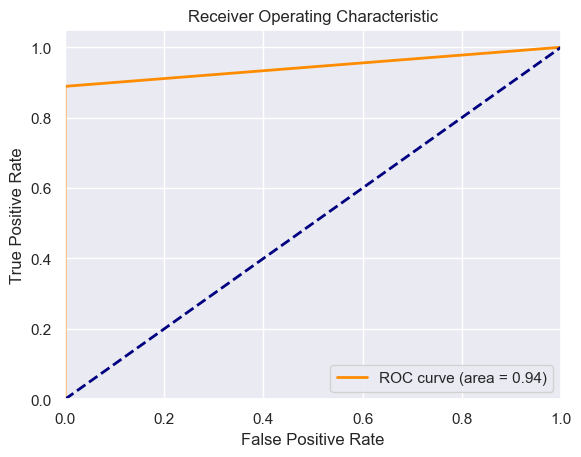

   False Positive Rate  True Positive Rate  Thresholds
0                  0.0            0.000000         inf
1                  0.0            0.888889         1.0
2                  1.0            1.000000         0.0


In [84]:
# Import necessary libraries
#Lets find the roc curve
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Display ROC table
roc_table = pd.DataFrame({
    'False Positive Rate': fpr,
    'True Positive Rate': tpr,
    'Thresholds': thresholds
})
print(roc_table)

In [85]:
#Lets try decision trees method
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.925
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95        31
           1       0.80      0.89      0.84         9

    accuracy                           0.93        40
   macro avg       0.88      0.91      0.90        40
weighted avg       0.93      0.93      0.93        40



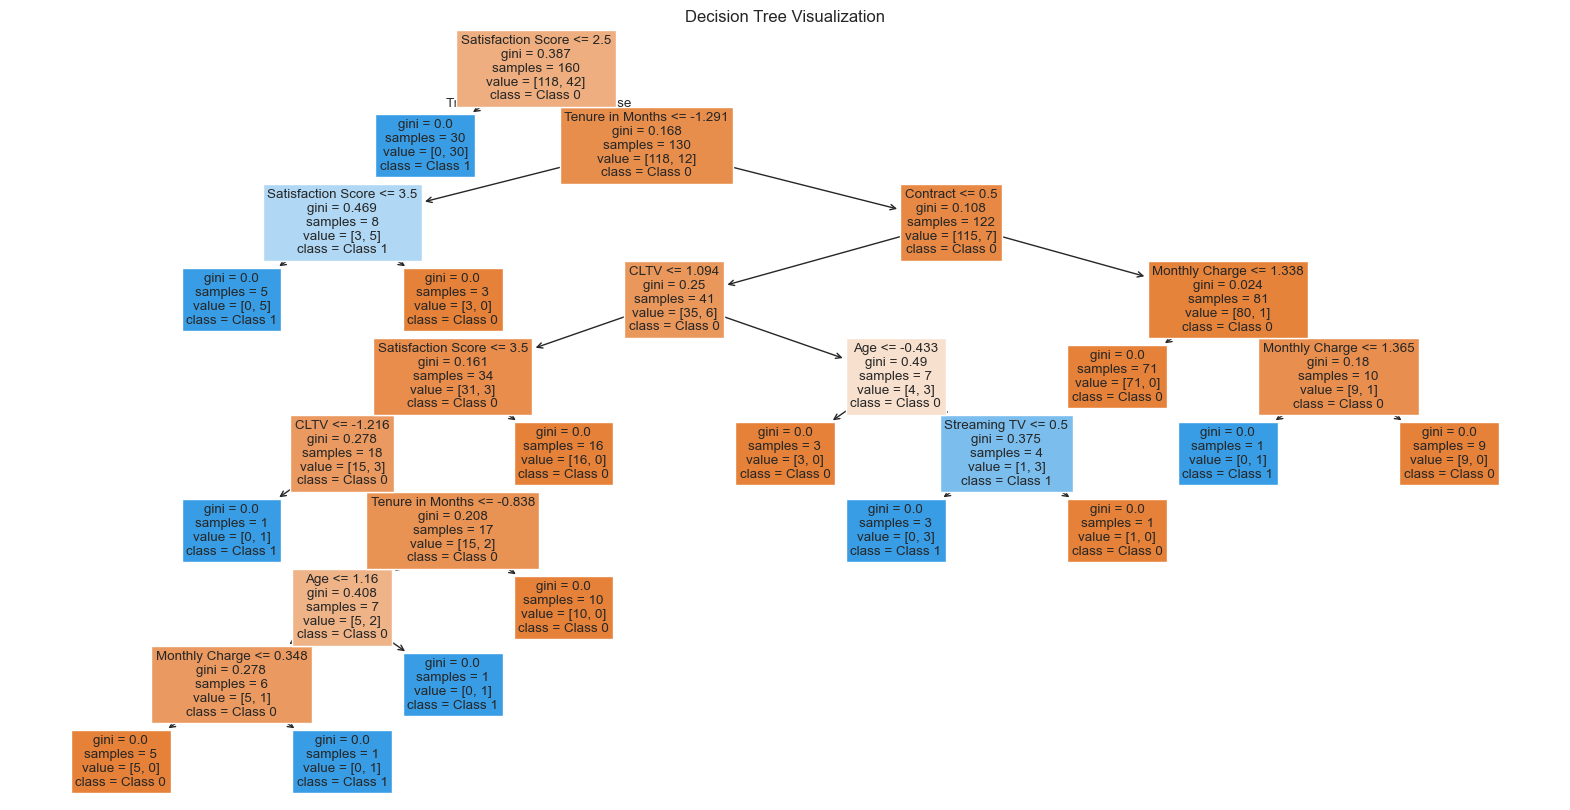

In [86]:
# Visualize the decision tree
plt.figure(figsize=(20,10))
tree.plot_tree(model, filled=True, feature_names=X.columns, class_names=['Class 0', 'Class 1'])
plt.title('Decision Tree Visualization')
plt.show()

When we use Decision Tree for classification:

1- Our accuracy score is 0.93 which shows that our model performs well.

2- Precision score when churn rate is 0 equals 0.97 and precision score when churn rate is 1 equals 0.80, which shows that our model is better at correctly identifying non-churning customers than churning ones.

3- Recall score when churn rate is 0 equals 0.94 and recall score when churn rate is 1 equals 0.89, which shows that our model is significantly better at identifying non-churning customers compared to churning ones.

4- F1-score when churn rate is 0 equals 0.95 and f1-score when churn rate is 1 equals 0.84, which shows an imbalance in performance between classes, with notably better performance for non-churning predictions.

5- Macro Avg F1 Score = 0.90: This indicates that, on average, the model's performance across both classes is moderate is good performance on churning customers, work equal for both classes.

6- Weighted Avg F1 Score = 0.93: This suggests that the model performs better than the macro average indicates when accounting for class distribution, likely due to having more non-churning customers in the dataset (31 vs 9 samples).

In [87]:
#Lets use k-nn method this time
from sklearn.neighbors import KNeighborsClassifier


# Initialize and train the k-NN model
k = 5  # You can choose a different value for k
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Evaluate the model
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.925
Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95        31
           1       1.00      0.67      0.80         9

    accuracy                           0.93        40
   macro avg       0.96      0.83      0.88        40
weighted avg       0.93      0.93      0.92        40



When we use 5-nn for classification:

1- Our accuracy score is 0.925 which shows that our model performs very well.

2- Precision score when churn rate is 0 equals 0.91 and precision score when churn rate is 1 equals 1, indicating strong performance in correctly identifying both churning and non-churning customers, with slightly better precision for non-churning cases.

3- Recall score when churn rate is 0 equals 1 and recall score when churn rate is 1 equals 0.67, showing that the model is excellent at identifying non-churning customers but struggles more with identifying churning customers.

4- F1-score when churn rate is 0 equals 0.95 and f1-score when churn rate is 1 equals 0.80, demonstrating better balanced performance for non-churning predictions compared to churning ones.

5- Macro Avg F1 Score = 0.88: This indicates that, on average, the model performs well across both classes, though there is some imbalance between the classes.

6- Weighted Avg F1 Score = 0.92: This suggests very good overall performance when accounting for class distribution, with the model performing better on the majority class (non-churning customers, 31 samples) compared to the minority class (churning customers, 8 samples).

When we checked the methods, Logistic regression and K-nn performed better than Decision Tree. 

In [88]:
#Lets work on discrimination for this data
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# Initialize and train the LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Evaluate the model
y_pred = lda.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.975
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        31
           1       1.00      0.89      0.94         9

    accuracy                           0.97        40
   macro avg       0.98      0.94      0.96        40
weighted avg       0.98      0.97      0.97        40



1- Our accuracy score is 0.975 which shows that our model performs too well there might be an overfitting. 

2- Precision score when churn rate is 0 equals 0.97 and precision score when churn rate is 1 equals 1, which shows that our model is slightly better at correctly identifying churning customers when it makes predictions.

3- Recall score when churn rate is 0 equals 1 and recall score when churn rate is 1 equals 0.89, which shows that our model is better at identifying non-churning customers, with some room for improvement in identifying churning customers.

4- F1-score when churn rate is 0 equals 0.98 and f1-score when churn rate is 1 equals 0.94, which shows that our model maintains a better balance between precision and recall for non-churning customers than churning ones.

5- Macro Avg F1 Score = 0.96: This indicates that, on average, the model performs well across both classes, treating each class equally regardless of its size.

6- Weighted Avg F1 Score = 0.97: This suggests that the model performs very well overall, taking into account the class distribution. The close alignment between macro and weighted averages indicates that class imbalance isn't significantly impacting the model's performance.

In [89]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
# Initialize and train the LDA model
lda = QuadraticDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Evaluate the model
y_pred = lda.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        31
           1       0.78      0.78      0.78         9

    accuracy                           0.90        40
   macro avg       0.86      0.86      0.86        40
weighted avg       0.90      0.90      0.90        40



When we use Quadratic Discrimination Analysis for classification:

1- Our accuracy score is 0,9 which shows that our model performs adequately, though there's room for improvement.

2- Precision score when churn rate is 0 equals 0.94 and precision score when churn rate is 1 equals 0.78, which shows that our model is notably better at correctly identifying non-churning customers than churning ones.

3- Recall score when churn rate is 0 equals 0.94 and recall score when churn rate is 1 equals 0.78, which shows that our model is much better at identifying non-churning customers.

4- F1-score when churn rate is 0 equals 0.94 and f1-score when churn rate is 1 equals 0.78, which shows a significant imbalance in performance between the classes, with the model performing much better for non-churning predictions.

5- Macro Avg F1 Score = 0.86: This indicates that, on average, the model's performance is moderate, with the low performance on churning customers bringing down the overall score.

6- Weighted Avg F1 Score = 0.90: This suggests that the model performs better than the macro average indicates when accounting for class distribution, but still shows room for improvement, particularly in identifying churning customers.

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

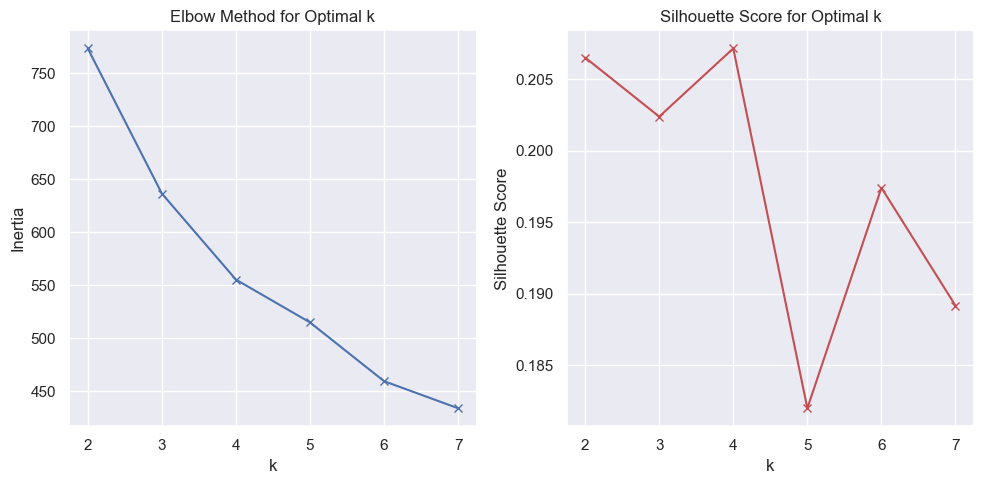

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Cluster Sizes:
Cluster
1    61
2    48
0    48
3    43
Name: count, dtype: int64

Cluster Characteristics (Numerical Features):
              Age  Tenure in Months  Monthly Charge      CLTV
Cluster                                                      
0        0.586409          1.036811        0.071914  0.864740
1       -0.437527         -0.592503       -1.103548 -0.390849
2        0.789135         -0.691551        0.557146 -0.657323
3       -0.914812          0.455121        0.863292  0.322925

Cluster Characteristics (Categorical Features):
               Contract Internet Type
Cluster                              
0              Two Year           DSL
1        Month-to-Month       No Type
2        Month-to-Month   Fiber Optic
3        Month-to-Month   Fiber Optic


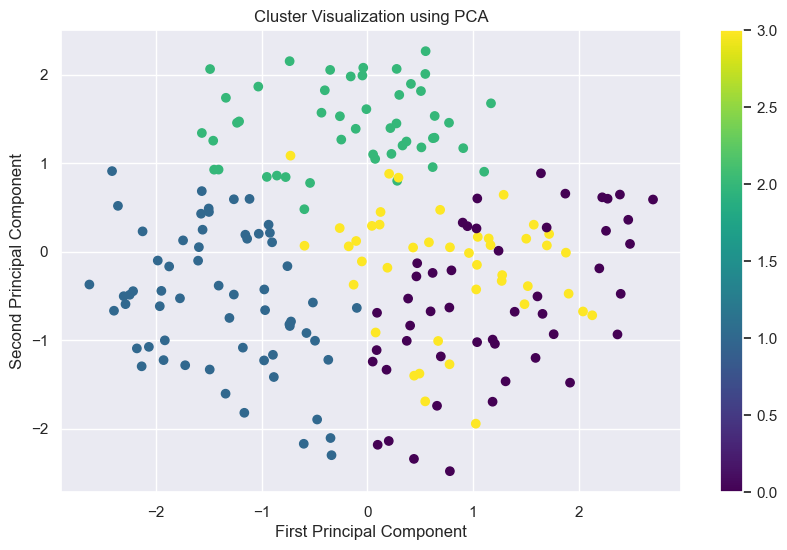

In [95]:
# First, let's prepare the data for clustering
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# Separate numerical and categorical columns
numerical_features = ['Age', 'Tenure in Months', 'Monthly Charge', 'CLTV']
categorical_features = ['Contract', 'Internet Type']

# Create preprocessing steps for both numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Prepare the data
X = df.drop('Churn', axis=1)  # Remove the target variable
X_processed = preprocessor.fit_transform(X)

# Apply K-means clustering
# Let's find the optimal number of clusters first
inertias = []
silhouette_scores = []
K = range(2, 8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_processed)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, kmeans.labels_))

# Plot elbow curve
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertias, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

# Plot silhouette scores
plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, 'rx-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()

# Apply final K-means with optimal k (let's say k=3 based on the plots)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_processed)

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels

# Analyze clusters
print("\nCluster Sizes:")
print(df['Cluster'].value_counts())

# Show mean values for numerical features by cluster
print("\nCluster Characteristics (Numerical Features):")
print(df.groupby('Cluster')[numerical_features].mean())

# Show mode values for categorical features by cluster
print("\nCluster Characteristics (Categorical Features):")
print(df.groupby('Cluster')[categorical_features].agg(lambda x: x.mode().iloc[0]))

# Visualize clusters using PCA for dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis')
plt.title('Cluster Visualization using PCA')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.colorbar(scatter)
plt.show()